# Lets Connect to Big Query using Google Colab!

Okay you have to import some packages to make Colab connect to Big Query


In [1]:
from google.colab import auth
auth.authenticate_user()
# You have to use the same Google login for BigQuery as Colab in order for this to work!

In [2]:
from google.cloud import bigquery
import pandas as pd

In [3]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "capstone-499014"
#Note this is MY Capstone ID, you should have another one! This is mine and mine alone.
client = bigquery.Client(project=PROJECT_ID)

In [4]:
query2 = """
SELECT *
FROM `capstone-499014.my_data.lung_cancer`
"""
# This is the natality_data from Big Query Public Data
df2 = client.query(query2).to_dataframe()

df2.head()

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,gender_encoded,family_history_encoded
0,13146,65.0,Female,Austria,2020-02-07,Stage II,False,Never Smoked,16.0,197,1,1,0,0,Chemotherapy,2021-01-05,0,0,0
1,51972,55.0,Female,Austria,2020-12-20,Stage I,False,Current Smoker,16.0,222,0,0,0,0,Combined,2022-02-25,0,0,0
2,90092,51.0,Female,Austria,2022-07-30,Stage I,False,Passive Smoker,16.0,157,1,0,0,0,Combined,2024-03-11,0,0,0
3,290503,70.0,Female,Austria,2017-09-09,Stage III,False,Never Smoked,16.0,237,1,1,0,0,Combined,2019-02-10,0,0,0
4,336198,54.0,Female,Austria,2020-05-28,Stage I,False,Current Smoker,16.0,226,0,1,0,1,Combined,2021-06-18,0,0,0



Now we can see what we have to do no?




In [5]:
df2.shape

(890000, 19)

### What are you going to do next?

In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890000 entries, 0 to 889999
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      890000 non-null  Int64  
 1   age                     890000 non-null  float64
 2   gender                  890000 non-null  object 
 3   country                 890000 non-null  object 
 4   diagnosis_date          890000 non-null  dbdate 
 5   cancer_stage            890000 non-null  object 
 6   family_history          890000 non-null  boolean
 7   smoking_status          890000 non-null  object 
 8   bmi                     890000 non-null  float64
 9   cholesterol_level       890000 non-null  Int64  
 10  hypertension            890000 non-null  Int64  
 11  asthma                  890000 non-null  Int64  
 12  cirrhosis               890000 non-null  Int64  
 13  other_cancer            890000 non-null  Int64  
 14  treatment_type      

In [7]:
df2.describe()

,id,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,survived,gender_encoded,family_history_encoded
count,890000.0,890000.000000,890000.000000,890000.0,890000.0,890000.0,890000.0,890000.0,890000.0,890000.0,890000.0
mean,445000.5,55.007008,30.494172,233.633916,0.750024,0.46974,0.225956,0.088157,0.220229,0.500151,0.499797
std,256921.014127,9.994485,8.368539,43.432278,0.432999,0.499084,0.418211,0.283524,0.414401,0.5,0.5
min,1.0,4.000000,16.000000,150.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,222500.75,48.000000,23.300000,196.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,445000.5,55.000000,30.500000,242.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
75%,667500.25,62.000000,37.700000,271.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
max,890000.0,104.000000,45.000000,300.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [8]:
df2.columns

Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived', 'gender_encoded',
       'family_history_encoded'],
      dtype='object')

In [9]:
(df2.astype(str) == '?').sum().sort_values(ascending=False)

,0
id,0
age,0
gender,0
country,0
diagnosis_date,0
cancer_stage,0
family_history,0
smoking_status,0
bmi,0
cholesterol_level,0


In [10]:
# Dataset feature summary table

feature_summary = pd.DataFrame({
    "Feature": [
        "id", "age", "gender", "country", "diagnosis_date", "cancer_stage",
        "family_history", "smoking_status", "bmi", "cholesterol_level",
        "hypertension", "asthma", "cirrhosis", "other_cancer",
        "treatment_type", "end_treatment_date", "survived"
    ],
    "Data Type": [
        "Numerical / Identifier", "Numerical", "Categorical", "Categorical", "Date", "Categorical",
        "Boolean / Categorical", "Categorical", "Numerical", "Numerical",
        "Binary Numerical", "Binary Numerical", "Binary Numerical", "Binary Numerical",
        "Categorical", "Date", "Binary Numerical"
    ],
    "Variable Category": [
        "Administrative", "Demographic", "Demographic", "Demographic", "Clinical", "Clinical",
        "Risk Factor", "Lifestyle", "Health Indicator", "Health Indicator",
        "Comorbidity", "Comorbidity", "Comorbidity", "Comorbidity",
        "Treatment", "Treatment", "Target Variable"
    ],
    "Description": [
        "Unique patient identifier.",
        "Patient age.",
        "Patient gender.",
        "Country associated with the patient record.",
        "Date when the patient was diagnosed with lung cancer.",
        "Stage of lung cancer.",
        "Indicates whether the patient has a family history of cancer.",
        "Patient smoking category.",
        "Body Mass Index of the patient.",
        "Patient cholesterol level.",
        "Indicates whether the patient has hypertension.",
        "Indicates whether the patient has asthma.",
        "Indicates whether the patient has cirrhosis.",
        "Indicates whether the patient has another type of cancer.",
        "Type of treatment received by the patient.",
        "Date when the treatment ended.",
        "Survival outcome: 0 = did not survive, 1 = survived."
    ]
})

feature_summary

,Feature,Data Type,Variable Category,Description
0,id,Numerical / Identifier,Administrative,Unique patient identifier.
1,age,Numerical,Demographic,Patient age.
2,gender,Categorical,Demographic,Patient gender.
3,country,Categorical,Demographic,Country associated with the patient record.
4,diagnosis_date,Date,Clinical,Date when the patient was diagnosed with lung ...
5,cancer_stage,Categorical,Clinical,Stage of lung cancer.
6,family_history,Boolean / Categorical,Risk Factor,Indicates whether the patient has a family his...
7,smoking_status,Categorical,Lifestyle,Patient smoking category.
8,bmi,Numerical,Health Indicator,Body Mass Index of the patient.
9,cholesterol_level,Numerical,Health Indicator,Patient cholesterol level.


# EDA

In [11]:
missing = (
    df2.isnull()
       .sum()
       .to_frame("Missing")
)

missing["Pct_Missing"] = round(
    missing["Missing"] / len(df2) * 100, 2
)

missing.sort_values(
    "Pct_Missing",
    ascending=False
).head(15)

,Missing,Pct_Missing
id,0,0.0
age,0,0.0
gender,0,0.0
country,0,0.0
diagnosis_date,0,0.0
cancer_stage,0,0.0
family_history,0,0.0
smoking_status,0,0.0
bmi,0,0.0
cholesterol_level,0,0.0


In [12]:
import matplotlib.pyplot as plt

In [13]:
# Descriptive statistics for numerical variables

numerical_vars = ["age", "bmi", "cholesterol_level"]

df2[numerical_vars].describe()

,age,bmi,cholesterol_level
count,890000.000000,890000.000000,890000.0
mean,55.007008,30.494172,233.633916
std,9.994485,8.368539,43.432278
min,4.000000,16.000000,150.0
25%,48.000000,23.300000,196.0
50%,55.000000,30.500000,242.0
75%,62.000000,37.700000,271.0
max,104.000000,45.000000,300.0


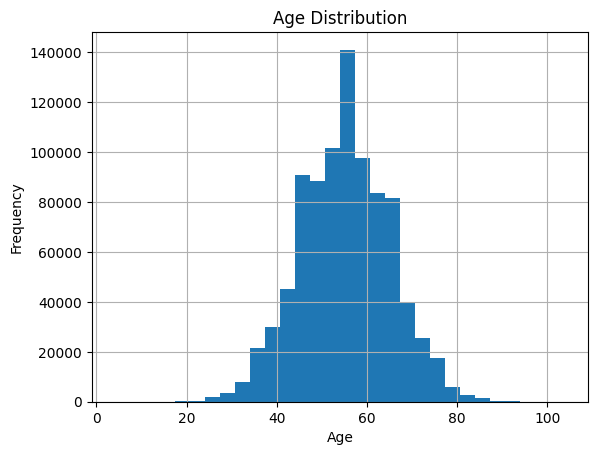

In [14]:
# Age Distribution

df2["age"].hist(bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

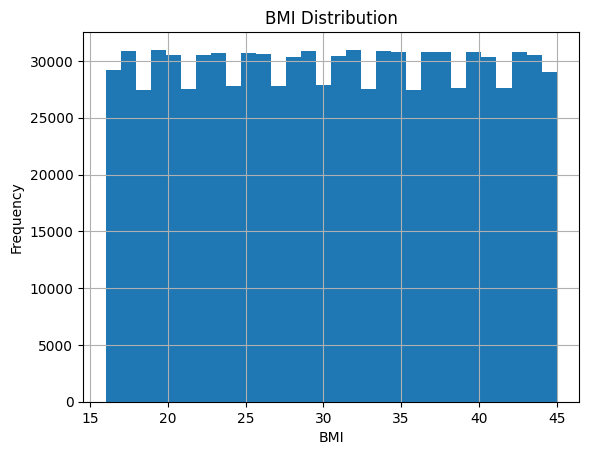

In [15]:
# BMI Distribution

df2["bmi"].hist(bins=30)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

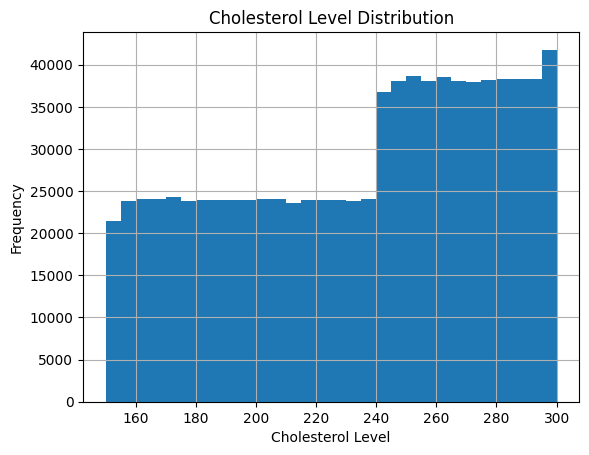

In [16]:
# Cholesterol level

df2["cholesterol_level"].hist(bins=30)

plt.title("Cholesterol Level Distribution")
plt.xlabel("Cholesterol Level")
plt.ylabel("Frequency")

plt.show()


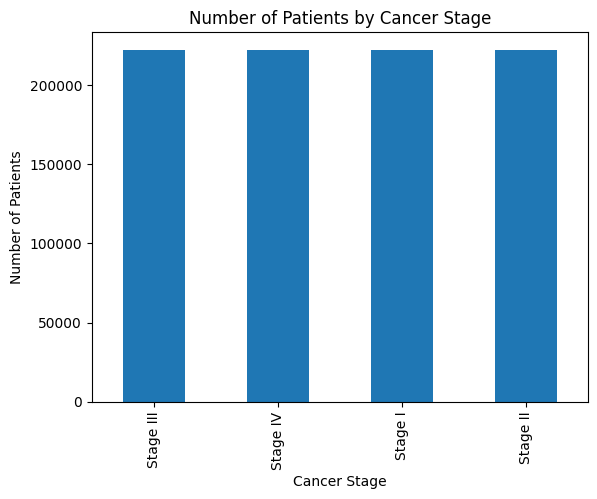

In [17]:
# Cancer stage

df2["cancer_stage"].value_counts().plot(kind="bar")

plt.title("Number of Patients by Cancer Stage")
plt.xlabel("Cancer Stage")
plt.ylabel("Number of Patients")

plt.show()

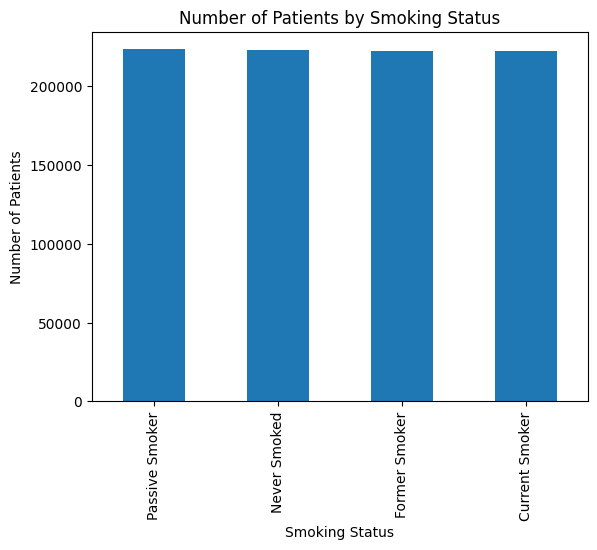

In [18]:
# Smoking status

df2["smoking_status"].value_counts().plot(kind="bar")

plt.title("Number of Patients by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")

plt.show()

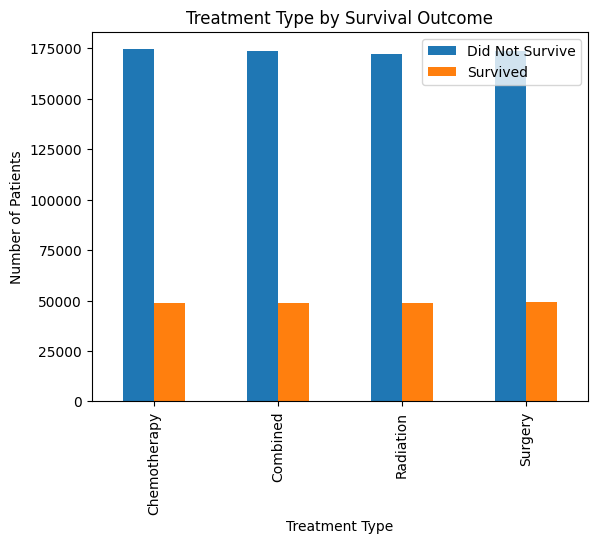

In [19]:
# Treatment type vs survival outcome
pd.crosstab(df2["treatment_type"], df2["survived"]).plot(kind="bar")

plt.title("Treatment Type by Survival Outcome")
plt.xlabel("Treatment Type")
plt.ylabel("Number of Patients")
plt.legend(["Did Not Survive", "Survived"])

plt.show()

In [20]:
def count_percentage_table(column):
    summary = pd.DataFrame({
        "count": df2[column].value_counts(),
        "percentage": (df2[column].value_counts(normalize=True) * 100).round(2)
    })
    return summary

In [21]:
# Count Gender

gender_summary = count_percentage_table("gender")
gender_summary



,count,percentage
gender,,
Male,445134,50.02
Female,444866,49.98


In [22]:
# Count Country

country_summary = pd.DataFrame({
    "count": df2["country"].value_counts().head(10),
    "percentage": (df2["country"].value_counts(normalize=True).head(10) * 100).round(2)
})

country_summary

,count,percentage
country,,
Malta,33367,3.75
Ireland,33243,3.74
Portugal,33208,3.73
France,33199,3.73
Sweden,33161,3.73
Croatia,33138,3.72
Greece,33052,3.71
Spain,33042,3.71
Netherlands,33040,3.71


In [23]:
# Count Family History

family_history_summary = count_percentage_table("family_history")
family_history_summary

,count,percentage
family_history,,
False,445181,50.02
True,444819,49.98


In [24]:
# Count Hypertension

hypertension_summary = count_percentage_table("hypertension")
hypertension_summary

,count,percentage
hypertension,,
1,667521,75.0
0,222479,25.0


In [25]:
# Count Asthma

asthma_summary = count_percentage_table("asthma")
asthma_summary

,count,percentage
asthma,,
0,471931,53.03
1,418069,46.97


In [26]:
# Count Cirrhosis

cirrhosis_summary = count_percentage_table("cirrhosis")
cirrhosis_summary

,count,percentage
cirrhosis,,
0,688899,77.4
1,201101,22.6


In [27]:
# Count Other Cancer

other_cancer_summary = count_percentage_table("other_cancer")
other_cancer_summary

,count,percentage
other_cancer,,
0,811540,91.18
1,78460,8.82


In [28]:
# Count Survived

survived_summary = count_percentage_table("survived")
survived_summary

,count,percentage
survived,,
0,693996,77.98
1,196004,22.02



# Create a prepared copy of the original dataset

df2 = original dataset

df2_clean =  used for encoding, feature engineering, and modeling


In [29]:
df2_clean = df2.copy()

# Check the new dataframe
print("Original dataset shape:", df2.shape)
print("Prepared dataset shape:", df2_clean.shape)

df2_clean.head()

Original dataset shape: (890000, 19)
Prepared dataset shape: (890000, 19)


,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,gender_encoded,family_history_encoded
0,13146,65.0,Female,Austria,2020-02-07,Stage II,False,Never Smoked,16.0,197,1,1,0,0,Chemotherapy,2021-01-05,0,0,0
1,51972,55.0,Female,Austria,2020-12-20,Stage I,False,Current Smoker,16.0,222,0,0,0,0,Combined,2022-02-25,0,0,0
2,90092,51.0,Female,Austria,2022-07-30,Stage I,False,Passive Smoker,16.0,157,1,0,0,0,Combined,2024-03-11,0,0,0
3,290503,70.0,Female,Austria,2017-09-09,Stage III,False,Never Smoked,16.0,237,1,1,0,0,Combined,2019-02-10,0,0,0
4,336198,54.0,Female,Austria,2020-05-28,Stage I,False,Current Smoker,16.0,226,0,1,0,1,Combined,2021-06-18,0,0,0


In [30]:
# Encoding Categorical Variables for Correlation Analysis

# Gender
df2_clean["gender_encoded"] = df2_clean["gender"].map({
    "Male": 1,
    "Female": 0
})

# Family History
df2_clean["family_history_encoded"] = df2_clean["family_history"].astype(int)

# Check results
df2_clean[["gender", "gender_encoded", "family_history", "family_history_encoded"]].head()

,gender,gender_encoded,family_history,family_history_encoded
0,Female,0,False,0
1,Female,0,False,0
2,Female,0,False,0
3,Female,0,False,0
4,Female,0,False,0


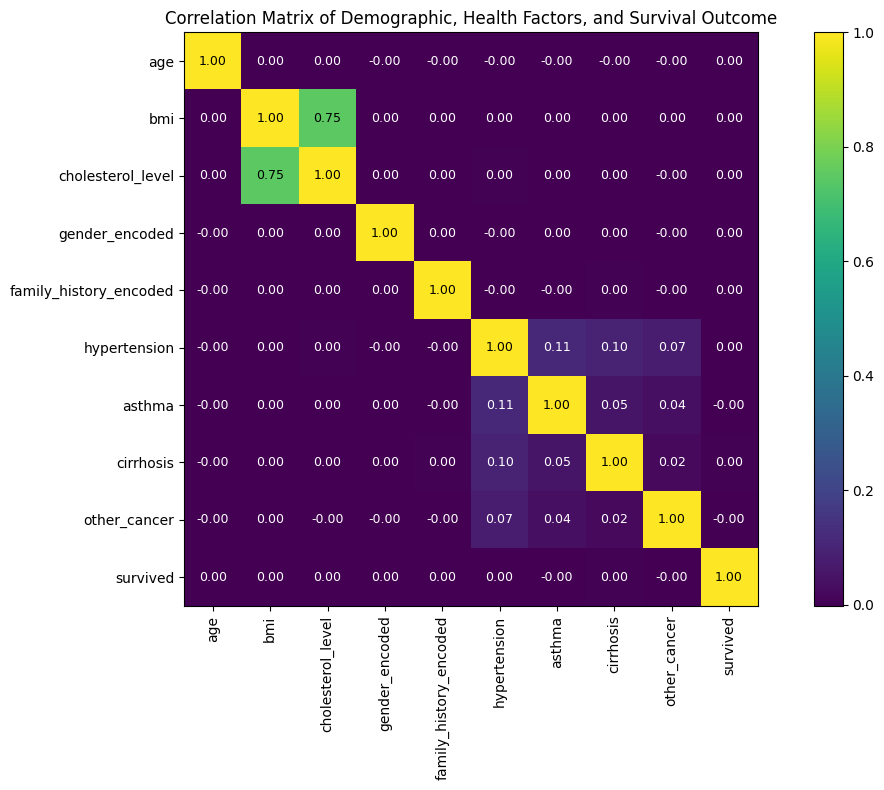

In [31]:
# Select variables for the correlation matrix

import matplotlib.pyplot as plt

corr_vars = df2_clean[
    [
        "age",
        "bmi",
        "cholesterol_level",
        "gender_encoded",
        "family_history_encoded",
        "hypertension",
        "asthma",
        "cirrhosis",
        "other_cancer",
        "survived"
    ]
]

# Create correlation matrix
corr = corr_vars.corr()

# Plot correlation matrix
plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="viridis")
plt.colorbar()

plt.title("Correlation Matrix of Demographic, Health Factors, and Survival Outcome")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add values inside each square
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        text_color = "black" if value > 0.5 else "white"
        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9
        )

plt.tight_layout()
plt.show()


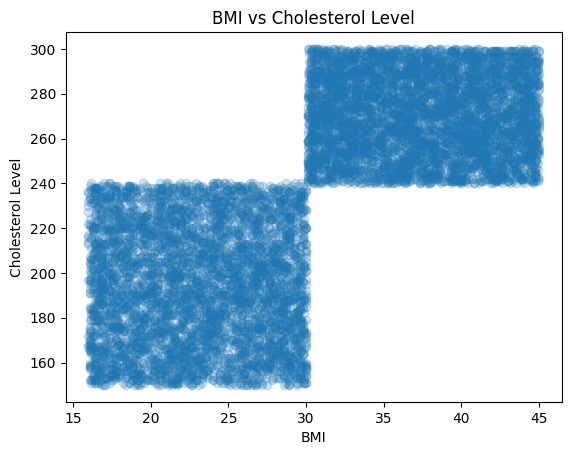

In [32]:
# BMI vs Cholesterol Level

sample = df2_clean.sample(10000, random_state=42)

plt.scatter(
    sample["bmi"],
    sample["cholesterol_level"],
    alpha=0.2
)

plt.title("BMI vs Cholesterol Level")
plt.xlabel("BMI")
plt.ylabel("Cholesterol Level")

plt.show()

# Cross Tabulation Analysis

Cross-tabulation analysis was used to compare categorical variables and identify patterns between patient characteristics.

In [33]:
# Treatment type vs survived

pd.crosstab(
    df2["treatment_type"],
    df2["survived"],
    normalize="index"
).mul(100).round(2)

survived,0,1
treatment_type,,
Chemotherapy,78.13,21.87
Combined,77.99,22.01
Radiation,77.94,22.06
Surgery,77.85,22.15


In [34]:
# Cancer stage vs survived

pd.crosstab(
    df2["cancer_stage"],
    df2["survived"],
    normalize="index"
).mul(100).round(2)

survived,0,1
cancer_stage,,
Stage I,78.19,21.81
Stage II,77.91,22.09
Stage III,77.95,22.05
Stage IV,77.86,22.14


In [35]:
# Smoking status vs cancer stage

pd.crosstab(
    df2["smoking_status"],
    df2["cancer_stage"],
    normalize="index"
).mul(100).round(2)

cancer_stage,Stage I,Stage II,Stage III,Stage IV
smoking_status,,,,
Current Smoker,25.05,24.98,25.11,24.87
Former Smoker,24.97,25.07,24.95,25.00
Never Smoked,25.03,24.90,24.95,25.11
Passive Smoker,24.95,24.99,25.03,25.02


In [36]:
# Smoking status vs cancer stage

pd.crosstab(
    df2["smoking_status"],
    df2["cancer_stage"],
    normalize="index"
).mul(100).round(2)



cancer_stage,Stage I,Stage II,Stage III,Stage IV
smoking_status,,,,
Current Smoker,25.05,24.98,25.11,24.87
Former Smoker,24.97,25.07,24.95,25.00
Never Smoked,25.03,24.90,24.95,25.11
Passive Smoker,24.95,24.99,25.03,25.02


In [37]:
# Family history vs survived

pd.crosstab(
    df2["family_history"],
    df2["survived"],
    normalize="index"
).mul(100).round(2)

survived,0,1
family_history,,
False,78.03,21.97
True,77.92,22.08


In [38]:
# Health conditions "Hypertension" vs survived

pd.crosstab(
    df2["hypertension"],
    df2["survived"],
    normalize="index"
).mul(100).round(2)


survived,0,1
hypertension,,
0,77.98,22.02
1,77.98,22.02


In [39]:
# Health conditions "Asma" vs survived

pd.crosstab(
    df2["asthma"],
    df2["survived"],
    normalize="index"
).mul(100).round(2)


survived,0,1
asthma,,
0,77.91,22.09
1,78.06,21.94


In [40]:
# Health conditions "Cirrhosis" vs survived

pd.crosstab(
    df2["cirrhosis"],
    df2["survived"],
    normalize="index"
).mul(100).round(2)

survived,0,1
cirrhosis,,
0,78.02,21.98
1,77.83,22.17


## Feature Engineering

Feature engineering was used to create new variables from existing columns. These new variables make the dataset easier to interpret data.


In [41]:
# Create BMI groups
df2_clean["bmi_group"] = pd.cut(
    df2_clean["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Create cholesterol groups
df2_clean["cholesterol_group"] = pd.cut(
    df2_clean["cholesterol_level"],
    bins=[0, 200, 240, 1000],
    labels=["Normal", "Borderline High", "High"]
)

# Create comorbidity variable
df2_clean["has_comorbidity"] = (
    (df2_clean["hypertension"] == 1) |
    (df2_clean["asthma"] == 1) |
    (df2_clean["cirrhosis"] == 1) |
    (df2_clean["other_cancer"] == 1)
)

# Check the new variables
df2_clean[
    [
        "gender",
        "gender_encoded",
        "family_history",
        "family_history_encoded",
        "bmi",
        "bmi_group",
        "cholesterol_level",
        "cholesterol_group",
        "hypertension",
        "asthma",
        "cirrhosis",
        "other_cancer",
        "has_comorbidity"
    ]
].head()

,gender,gender_encoded,family_history,family_history_encoded,bmi,bmi_group,cholesterol_level,cholesterol_group,hypertension,asthma,cirrhosis,other_cancer,has_comorbidity
0,Female,0,False,0,16.0,Underweight,197,Normal,1,1,0,0,True
1,Female,0,False,0,16.0,Underweight,222,Borderline High,0,0,0,0,False
2,Female,0,False,0,16.0,Underweight,157,Normal,1,0,0,0,True
3,Female,0,False,0,16.0,Underweight,237,Borderline High,1,1,0,0,True
4,Female,0,False,0,16.0,Underweight,226,Borderline High,0,1,0,1,True


In [42]:
# Analyze survival outcome by comorbidity status
pd.crosstab(
    df2_clean["has_comorbidity"],
    df2_clean["survived"],
    normalize="index"
).mul(100).round(2)

survived,0,1
has_comorbidity,,
False,77.95,22.05
True,77.98,22.02


Preview of predictor variables:


,age,bmi,cholesterol_level,gender_encoded,family_history_encoded,hypertension,asthma,cirrhosis,other_cancer,cancer_stage_Stage II,...,smoking_status_Passive Smoker,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery,bmi_group_Normal,bmi_group_Overweight,bmi_group_Obese,cholesterol_group_Borderline High,cholesterol_group_High,has_comorbidity_True
0,65.0,16.0,197,0,0,1,1,0,0,True,...,False,False,False,False,False,False,False,False,False,True
1,55.0,16.0,222,0,0,0,0,0,0,False,...,False,True,False,False,False,False,False,True,False,False
2,51.0,16.0,157,0,0,1,0,0,0,False,...,True,True,False,False,False,False,False,False,False,True
3,70.0,16.0,237,0,0,1,1,0,0,False,...,False,True,False,False,False,False,False,True,False,True
4,54.0,16.0,226,0,0,0,1,0,1,False,...,False,True,False,False,False,False,False,True,False,True


X shape: (890000, 24)
y shape: (890000,)

Target variable distribution:
survived
0    77.98
1    22.02
Name: proportion, dtype: Float64

Training set shape: (712000, 24)
Testing set shape: (178000, 24)


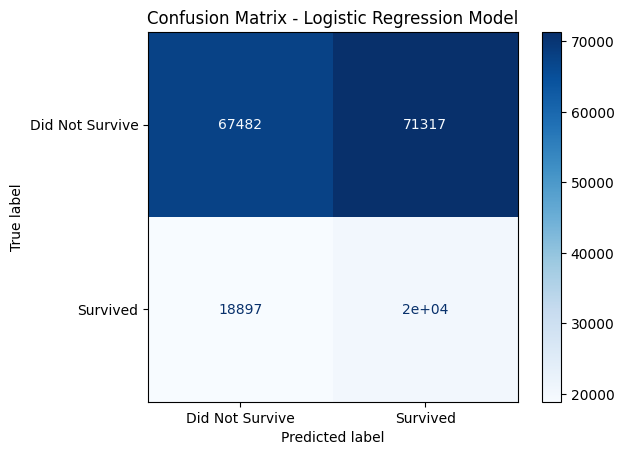

Confusion Matrix:
[[67482 71317]
 [18897 20304]]

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.78      0.49      0.60    138799
       Survived       0.22      0.52      0.31     39201

       accuracy                           0.49    178000
      macro avg       0.50      0.50      0.45    178000
   weighted avg       0.66      0.49      0.54    178000

ROC-AUC Score: 0.5029

Top 15 Most Important Features Based on Logistic Regression Coefficients:


,Feature,Coefficient,Absolute_Coefficient
9,cancer_stage_Stage II,0.019144,0.019144
11,cancer_stage_Stage IV,0.016480,0.016480
17,treatment_type_Surgery,0.015207,0.015207
7,cirrhosis,0.014207,0.014207
10,cancer_stage_Stage III,0.012684,0.012684
16,treatment_type_Radiation,0.012455,0.012455
8,other_cancer,-0.010917,0.010917
6,asthma,-0.008211,0.008211
22,cholesterol_group_High,0.006539,0.006539
19,bmi_group_Overweight,-0.006039,0.006039


In [43]:
# Predictive Model: Survival Outcome
# Logistic Regression Model

# Step 1: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)


# Step 2: Define target variable


# Target variable:
# 0 = Did Not Survive
# 1 = Survived

y = df2_clean["survived"]


# Step 3: Select predictor variables


X = df2_clean[
    [
        "age",
        "bmi",
        "cholesterol_level",
        "gender_encoded",
        "family_history_encoded",
        "hypertension",
        "asthma",
        "cirrhosis",
        "other_cancer",
        "cancer_stage",
        "smoking_status",
        "treatment_type",
        "bmi_group",
        "cholesterol_group",
        "has_comorbidity"
    ]
]


# Step 4: Convert categorical variables into numeric variables


X = pd.get_dummies(
    X,
    columns=[
        "cancer_stage",
        "smoking_status",
        "treatment_type",
        "bmi_group",
        "cholesterol_group",
        "has_comorbidity"
    ],
    drop_first=True
)


# Step 5: Check final model dataset


print("Preview of predictor variables:")
display(X.head())

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget variable distribution:")
print(y.value_counts(normalize=True).mul(100).round(2))


# Step 6: Split the data into training and testing sets


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


# Step 7: Train the Logistic Regression model


model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)


# Step 8: Make predictions


y_pred = model.predict(X_test)

# Predict probabilities for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]


# Step 9: Confusion Matrix


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression Model")
plt.show()

print("Confusion Matrix:")
print(cm)


# Step 10: Classification Report

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Did Not Survive", "Survived"]
    )
)


# Step 11: ROC-AUC Score


roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))


# Step 12: Feature Coefficients


coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("\nTop 15 Most Important Features Based on Logistic Regression Coefficients:")
display(coefficients.head(15))

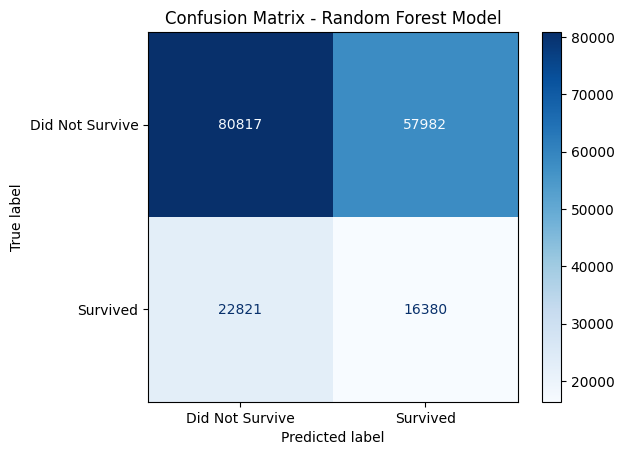

Confusion Matrix:
[[80817 57982]
 [22821 16380]]

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.78      0.58      0.67    138799
       Survived       0.22      0.42      0.29     39201

       accuracy                           0.55    178000
      macro avg       0.50      0.50      0.48    178000
   weighted avg       0.66      0.55      0.58    178000

ROC-AUC Score: 0.501

Top 15 Most Important Features:


,Feature,Importance
1,bmi,0.215470
0,age,0.201460
2,cholesterol_level,0.184587
4,family_history_encoded,0.029981
3,gender_encoded,0.028082
7,cirrhosis,0.024957
6,asthma,0.024838
5,hypertension,0.023777
8,other_cancer,0.023372
13,smoking_status_Never Smoked,0.022484


In [44]:
# Improved Predictive Model: Random Forest


# Step 1: Import Libries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)


#  Step 2: Target variable
y = df2_clean["survived"]


#  Step 3: Predictor variables
X = df2_clean[
    [
        "age",
        "bmi",
        "cholesterol_level",
        "gender_encoded",
        "family_history_encoded",
        "hypertension",
        "asthma",
        "cirrhosis",
        "other_cancer",
        "cancer_stage",
        "smoking_status",
        "treatment_type",
        "bmi_group",
        "cholesterol_group",
        "has_comorbidity"
    ]
]

#  Step 4: One-hot encoding for categorical variables
X = pd.get_dummies(
    X,
    columns=[
        "cancer_stage",
        "smoking_status",
        "treatment_type",
        "bmi_group",
        "cholesterol_group",
        "has_comorbidity"
    ],
    drop_first=True
)

#  Step 5: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#  Step 6: Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

#  Step 7: Train model
rf_model.fit(X_train, y_train)


# Step 8: Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


#  Step 9: Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest Model")
plt.show()

print("Confusion Matrix:")
print(cm_rf)

#  Step 10. Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Did Not Survive", "Survived"]
    )
)

#  Step 11. ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC Score:", round(roc_auc_rf, 4))

#  Step 12. Feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Most Important Features:")
display(feature_importance.head(15))

Lung Cancer Dataset Analysis Using BigQuery and Python

A clean copy of the original lung cancer dataset was created to preserve the original BigQuery table. The cleaned version includes encoded variables for gender and family history, which were created for the correlation analysis. This cleaned table will be uploaded to BigQuery as `lung_cancer_cleaned`.

In [45]:
from pandas_gbq import to_gbq

# Create a clean copy of the original dataset
df2_clean = df2.copy()

# Encode gender: Male = 1, Female = 0
df2_clean["gender_encoded"] = df2_clean["gender"].map({
    "Male": 1,
    "Female": 0
})

# Encode family history: True = 1, False = 0
df2_clean["family_history_encoded"] = df2_clean["family_history"].astype(int)

# Create BMI groups
df2_clean["bmi_group"] = pd.cut(
    df2_clean["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Create cholesterol groups
df2_clean["cholesterol_group"] = pd.cut(
    df2_clean["cholesterol_level"],
    bins=[0, 200, 240, 1000],
    labels=["Normal", "Borderline High", "High"]
)

# Create comorbidity variable
df2_clean["has_comorbidity"] = (
    (df2_clean["hypertension"] == 1) |
    (df2_clean["asthma"] == 1) |
    (df2_clean["cirrhosis"] == 1) |
    (df2_clean["other_cancer"] == 1)
)

# Upload cleaned dataset to BigQuery
to_gbq(
    df2_clean,
    destination_table="my_data.lung_cancer_cleaned",
    project_id="capstone-499014",
    if_exists="replace"
)

100%|██████████| 1/1 [00:00<00:00, 9709.04it/s]


In [46]:
from pandas_gbq import to_gbq

to_gbq(
    df2_clean,
    destination_table='my_data.lung_cancer_cleaned',
    project_id='capstone-499014',
    if_exists='replace'
)

100%|██████████| 1/1 [00:00<00:00, 8112.77it/s]


In [47]:
query = """
SELECT *
FROM `capstone-499014.my_data.lung_cancer_cleaned`
"""

df_clean = client.query(query).to_dataframe()

df_clean.head()

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,...,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived,gender_encoded,family_history_encoded,bmi_group,cholesterol_group,has_comorbidity
0,13146,65.0,Female,Austria,2020-02-07,Stage II,False,Never Smoked,16.0,197,...,0,0,Chemotherapy,2021-01-05,0,0,0,Underweight,Normal,True
1,51972,55.0,Female,Austria,2020-12-20,Stage I,False,Current Smoker,16.0,222,...,0,0,Combined,2022-02-25,0,0,0,Underweight,Borderline High,False
2,90092,51.0,Female,Austria,2022-07-30,Stage I,False,Passive Smoker,16.0,157,...,0,0,Combined,2024-03-11,0,0,0,Underweight,Normal,True
3,290503,70.0,Female,Austria,2017-09-09,Stage III,False,Never Smoked,16.0,237,...,0,0,Combined,2019-02-10,0,0,0,Underweight,Borderline High,True
4,336198,54.0,Female,Austria,2020-05-28,Stage I,False,Current Smoker,16.0,226,...,0,1,Combined,2021-06-18,0,0,0,Underweight,Borderline High,True
